In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
data_path = 'mobile_addiction_data.csv'
df = pd.read_csv(data_path, encoding='ascii', delimiter=',')

In [3]:
df.head()

,User_ID,Country,Age,Gender,Occupation,Education_Level,Income_USD,Daily_Screen_Time_Hours,Phone_Unlocks_Per_Day,Social_Media_Usage_Hours,...,Online_Shopping_Hours,Internet_Connection_Type,Primary_Device_Brand,Has_Screen_Time_Management_App,Self_Reported_Addiction_Level,Monthly_Data_Usage_GB,Has_Night_Mode_On,Age_First_Phone,Push_Notifications_Per_Day,Tech_Savviness_Score
0,1,India,32,Male,Salesperson,High School,43865.49,5.81,75,0.84,...,1.85,5G,Other,No,Low,16.43,Yes,16,106,39.36
1,2,UK,26,Male,Artist,Master's,41868.19,9.05,61,3.13,...,0.66,4G,Samsung,Yes,Severe,32.87,No,12,111,9.45
2,3,Germany,70,Other,Doctor,High School,59636.51,5.76,58,2.12,...,-0.14,WiFi,Samsung,Yes,Severe,27.45,No,18,90,50.27
3,4,UK,44,Female,Engineer,NaN,39022.07,6.71,80,1.60,...,0.17,3G,Apple,Yes,Moderate,30.85,No,17,60,30.82
4,5,Brazil,46,Other,Student,NaN,-783.98,6.31,136,1.51,...,0.58,3G,Xiaomi,No,High,10.38,Yes,18,127,21.70


In [4]:
print('Missing values per column:')
print(df.isnull().sum())

numeric_cols = df.select_dtypes(include=[np.number]).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

categorical_cols = df.select_dtypes(include=[object]).columns
for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

print('Data cleaning completed.')

Missing values per column:
User_ID                             0
Country                             0
Age                                 0
Gender                              0
Occupation                          0
Education_Level                   612
Income_USD                          0
Daily_Screen_Time_Hours             0
Phone_Unlocks_Per_Day               0
Social_Media_Usage_Hours            0
Gaming_Usage_Hours                  0
Streaming_Usage_Hours               0
Messaging_Usage_Hours               0
Work_Related_Usage_Hours            0
Sleep_Hours                         0
Physical_Activity_Hours             0
Mental_Health_Score                 0
Depression_Score                    0
Anxiety_Score                       0
Stress_Level                        0
Relationship_Status                 0
Has_Children                        0
Urban_or_Rural                      0
Time_Spent_With_Family_Hours        0
Online_Shopping_Hours               0
Internet_Connection_Typ

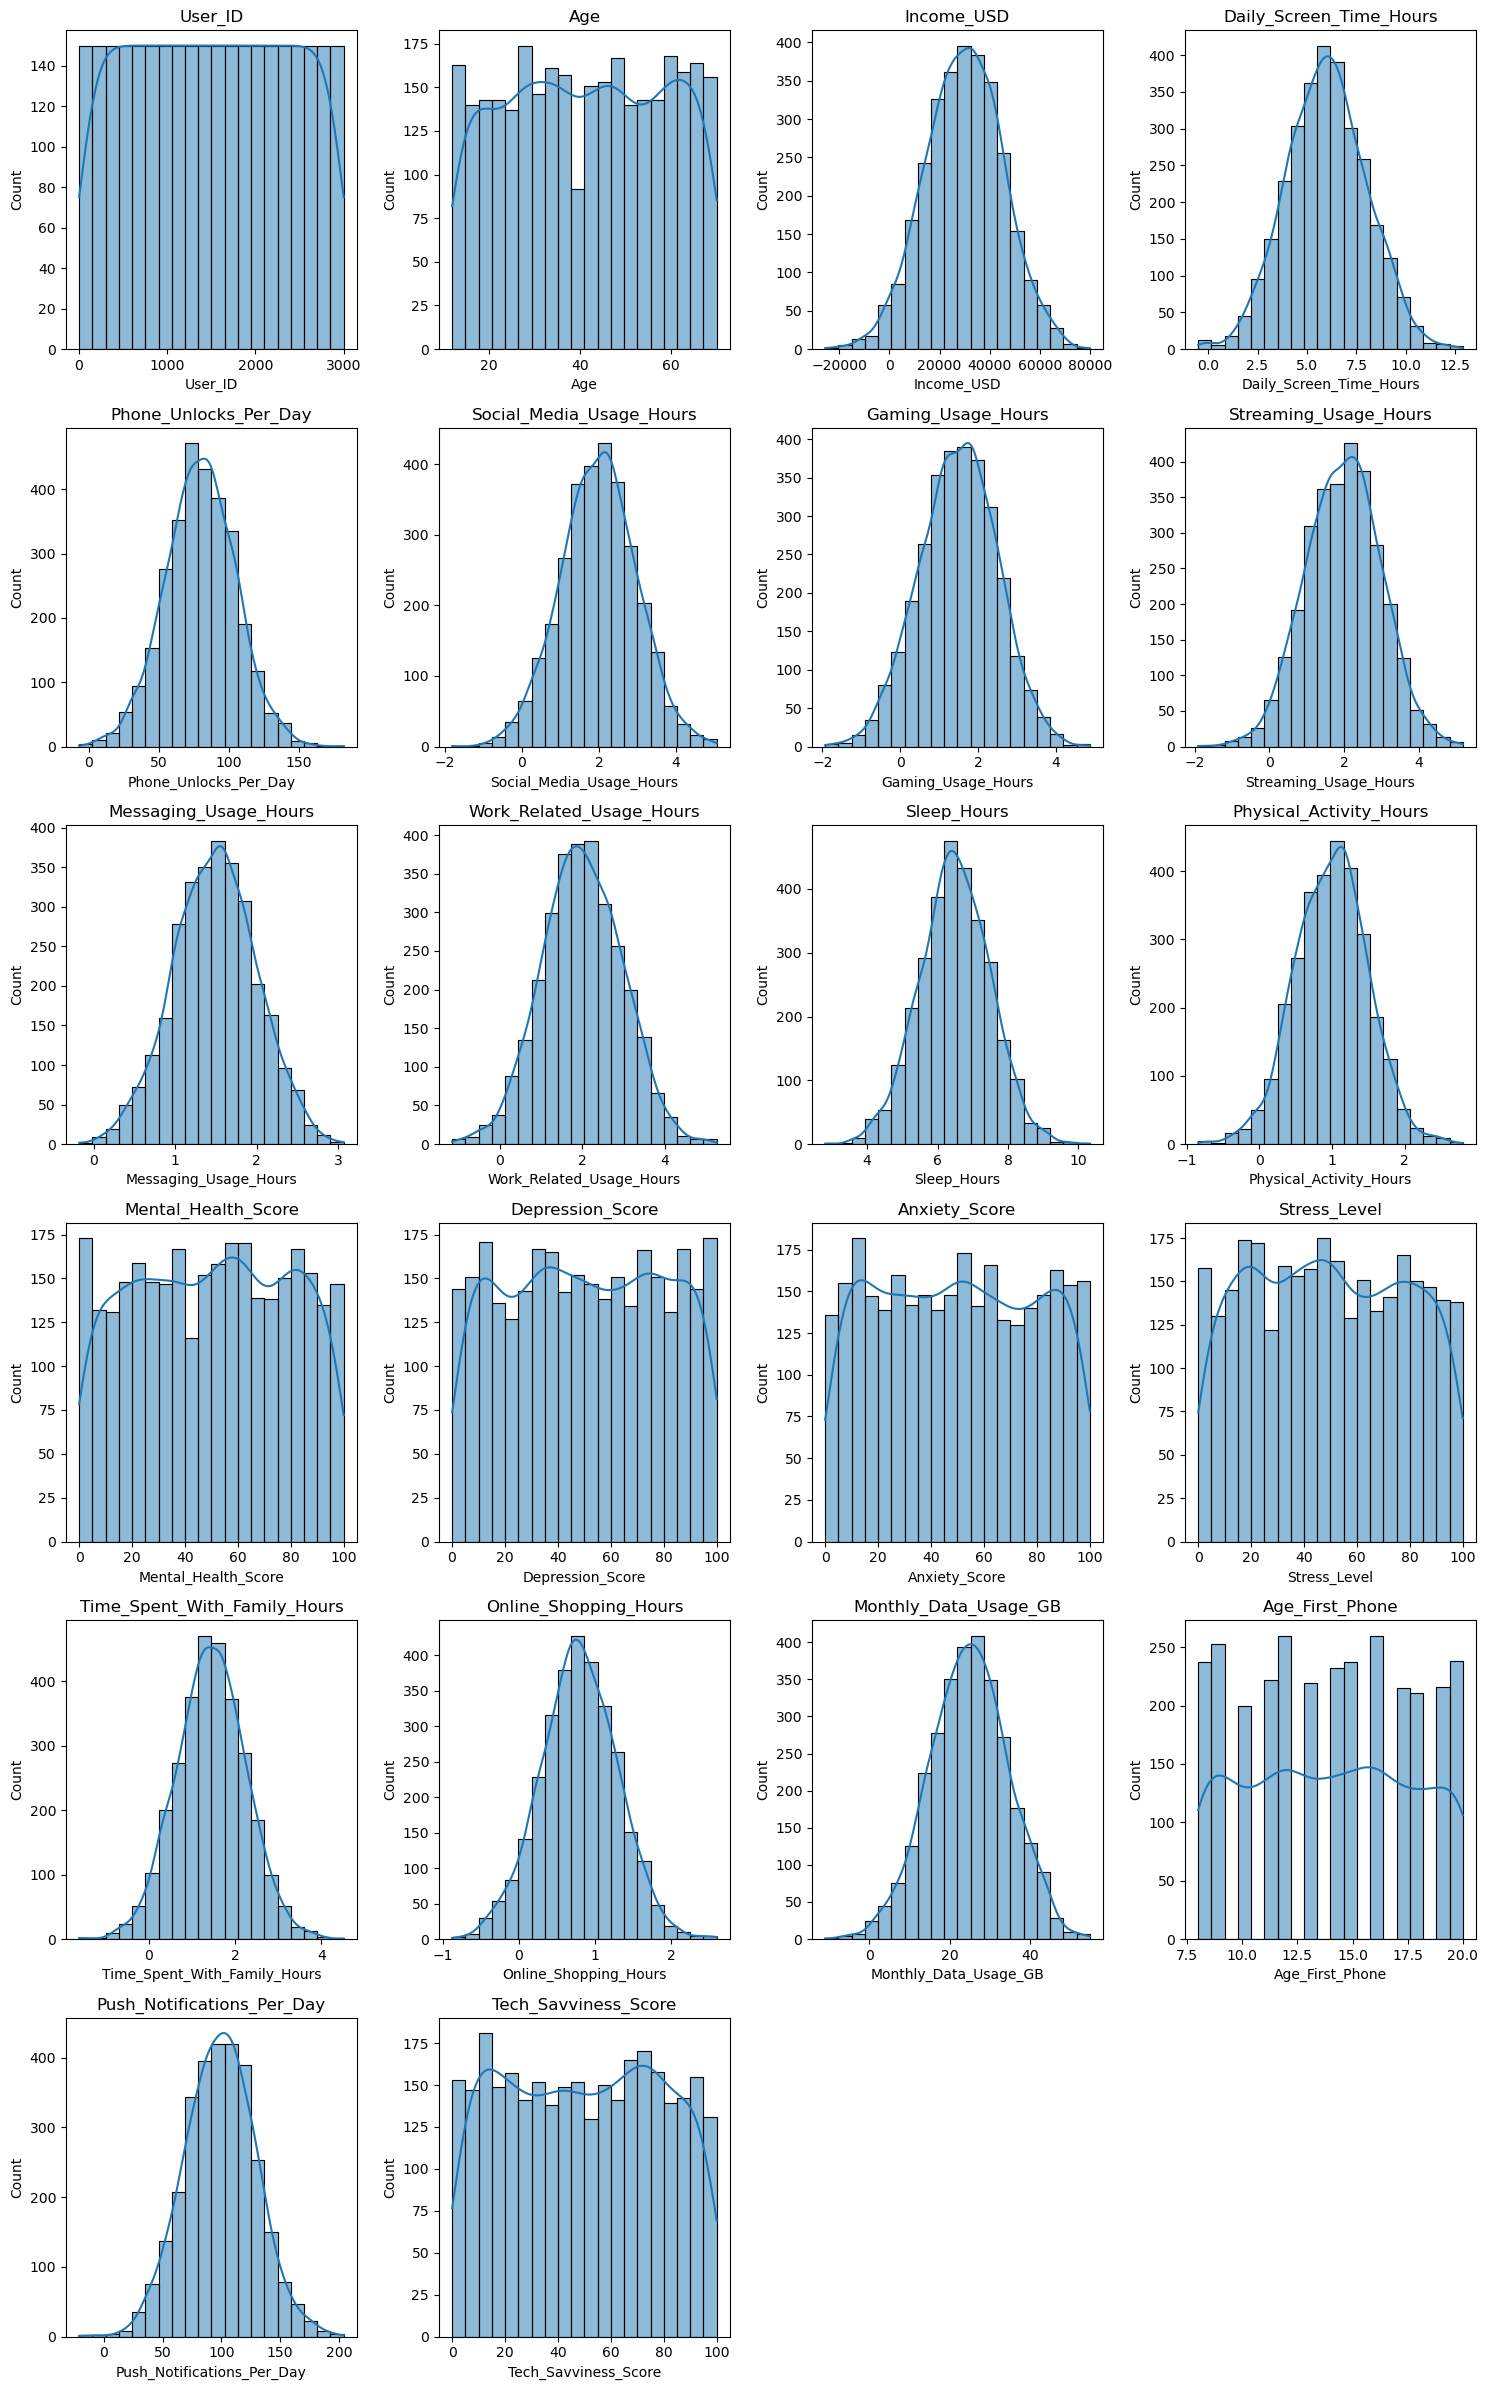

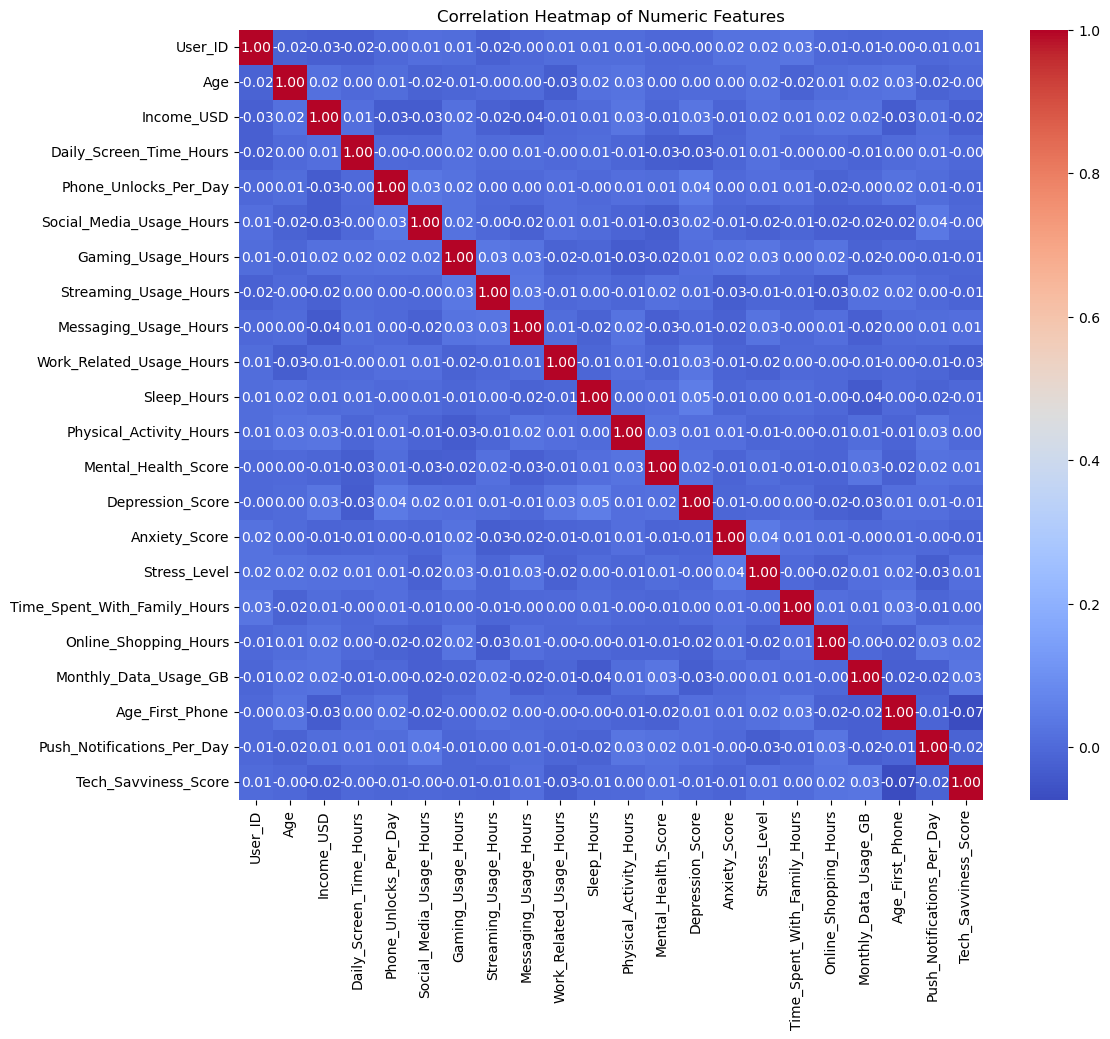

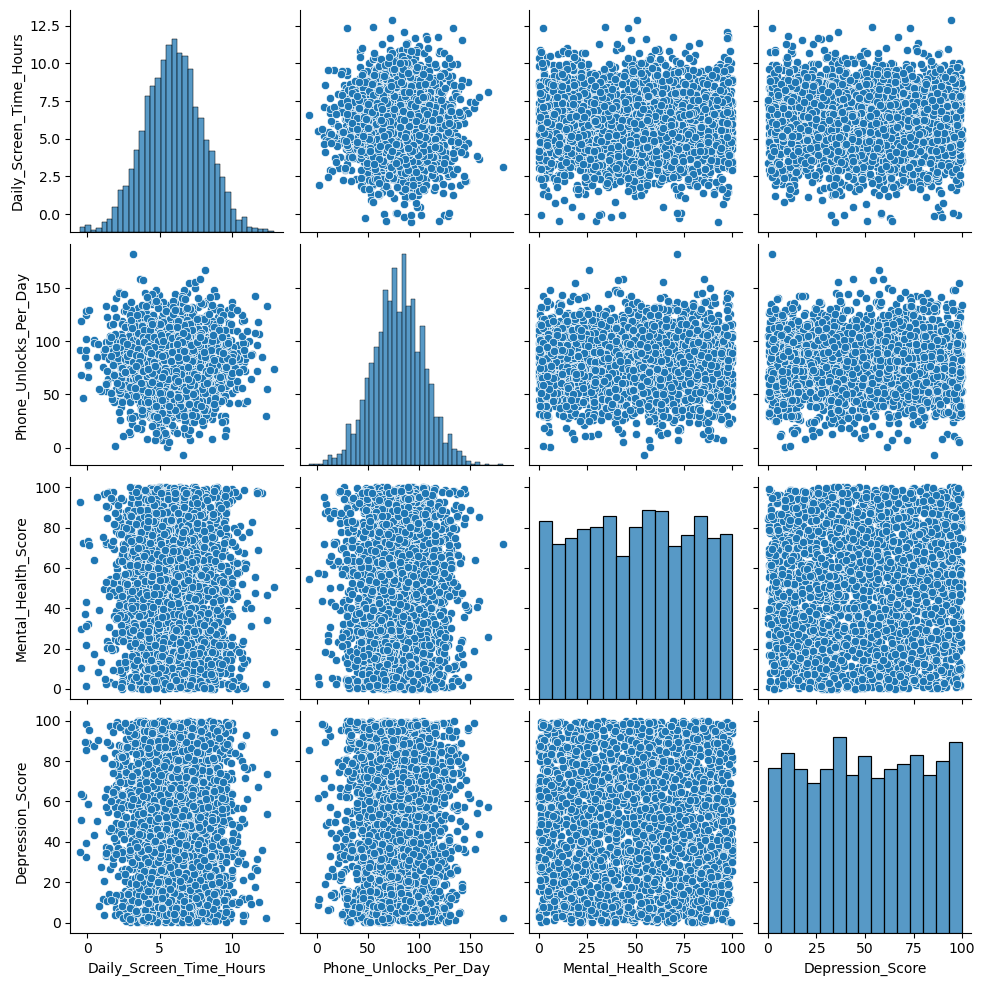

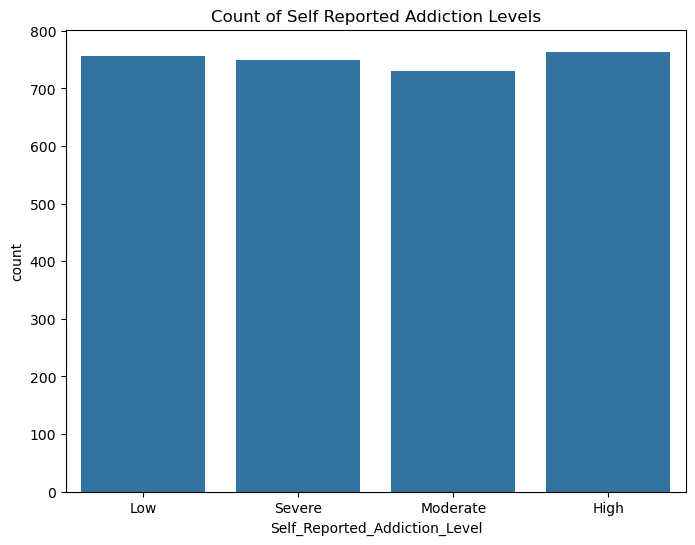

In [5]:
# EDA: 

import math

numeric_df = df.select_dtypes(include=[np.number])
numeric_columns = numeric_df.columns

num_plots = len(numeric_columns)
num_cols = 4
num_rows = math.ceil(num_plots / num_cols)

plt.figure(figsize=(15, 4 * num_rows))
for idx, col in enumerate(numeric_columns):
    plt.subplot(num_rows, num_cols, idx+1)
    sns.histplot(df[col].dropna(), kde=True, bins=20)
    plt.title(col)
plt.tight_layout()
plt.show()

if len(numeric_columns) >= 4:
    plt.figure(figsize=(12, 10))
    corr = numeric_df.corr()
    sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
    plt.title('Correlation Heatmap of Numeric Features')
    plt.show()

subset_cols = ['Daily_Screen_Time_Hours', 'Phone_Unlocks_Per_Day', 'Mental_Health_Score', 'Depression_Score']
if all(col in df.columns for col in subset_cols):
    sns.pairplot(df[subset_cols].dropna())
    plt.show()

plt.figure(figsize=(8, 6))
sns.countplot(x='Self_Reported_Addiction_Level', data=df)
plt.title('Count of Self Reported Addiction Levels')
plt.show()

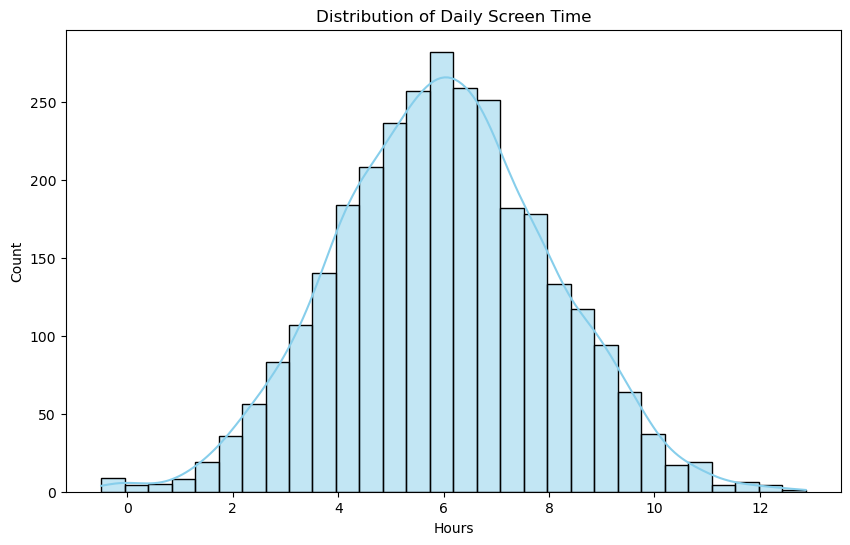

In [6]:
plt.figure(figsize=(10, 6))
sns.histplot(df["Daily_Screen_Time_Hours"], kde=True, bins=30, color='skyblue')
plt.title("Distribution of Daily Screen Time")
plt.xlabel("Hours")
plt.ylabel("Count")
plt.show()

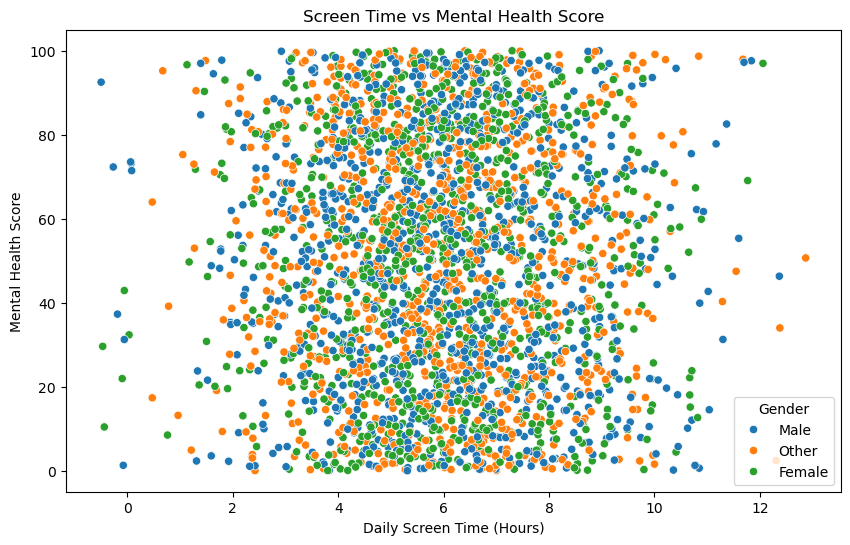

In [7]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x="Daily_Screen_Time_Hours", y="Mental_Health_Score", hue="Gender")
plt.title("Screen Time vs Mental Health Score")
plt.xlabel("Daily Screen Time (Hours)")
plt.ylabel("Mental Health Score")
plt.show()

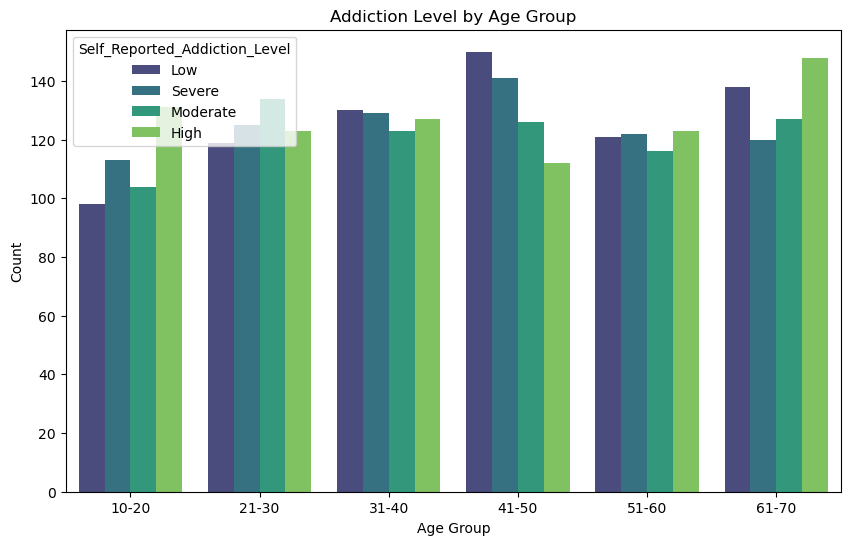

In [8]:
df["Age_Group"] = pd.cut(df["Age"], bins=[10, 20, 30, 40, 50, 60, 70], labels=["10-20", "21-30", "31-40", "41-50", "51-60", "61-70"])

plt.figure(figsize=(10, 6))
sns.countplot(data=df, x="Age_Group", hue="Self_Reported_Addiction_Level", palette="viridis")
plt.title("Addiction Level by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Count")
plt.show()


C:\Users\DELL\AppData\Local\Temp\ipykernel_14776\3492429307.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x="Occupation", y="Daily_Screen_Time_Hours", palette="magma")


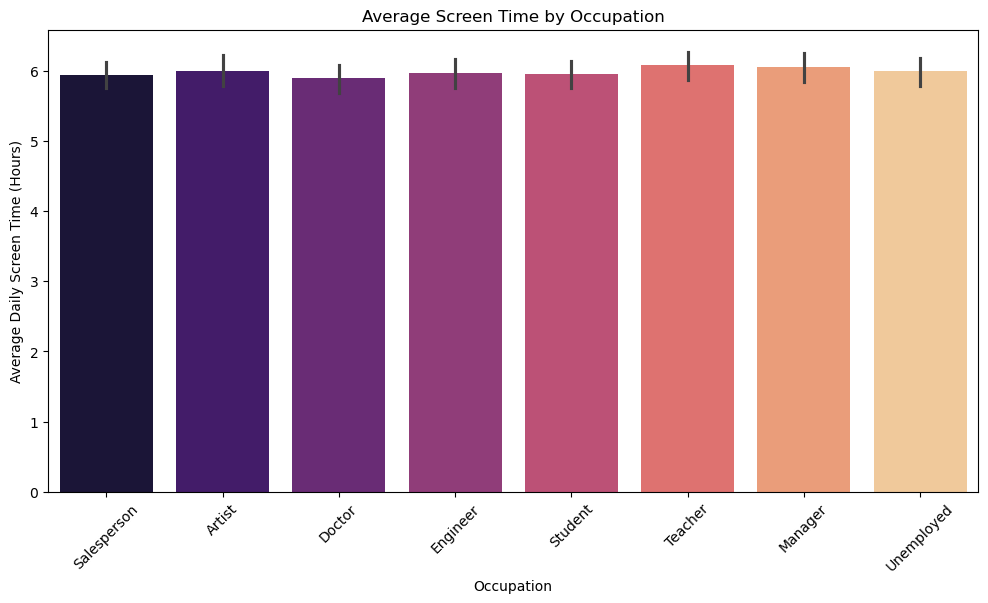

In [9]:
plt.figure(figsize=(12, 6))
sns.barplot(data=df, x="Occupation", y="Daily_Screen_Time_Hours", palette="magma")
plt.title("Average Screen Time by Occupation")
plt.xticks(rotation=45)
plt.ylabel("Average Daily Screen Time (Hours)")
plt.show()

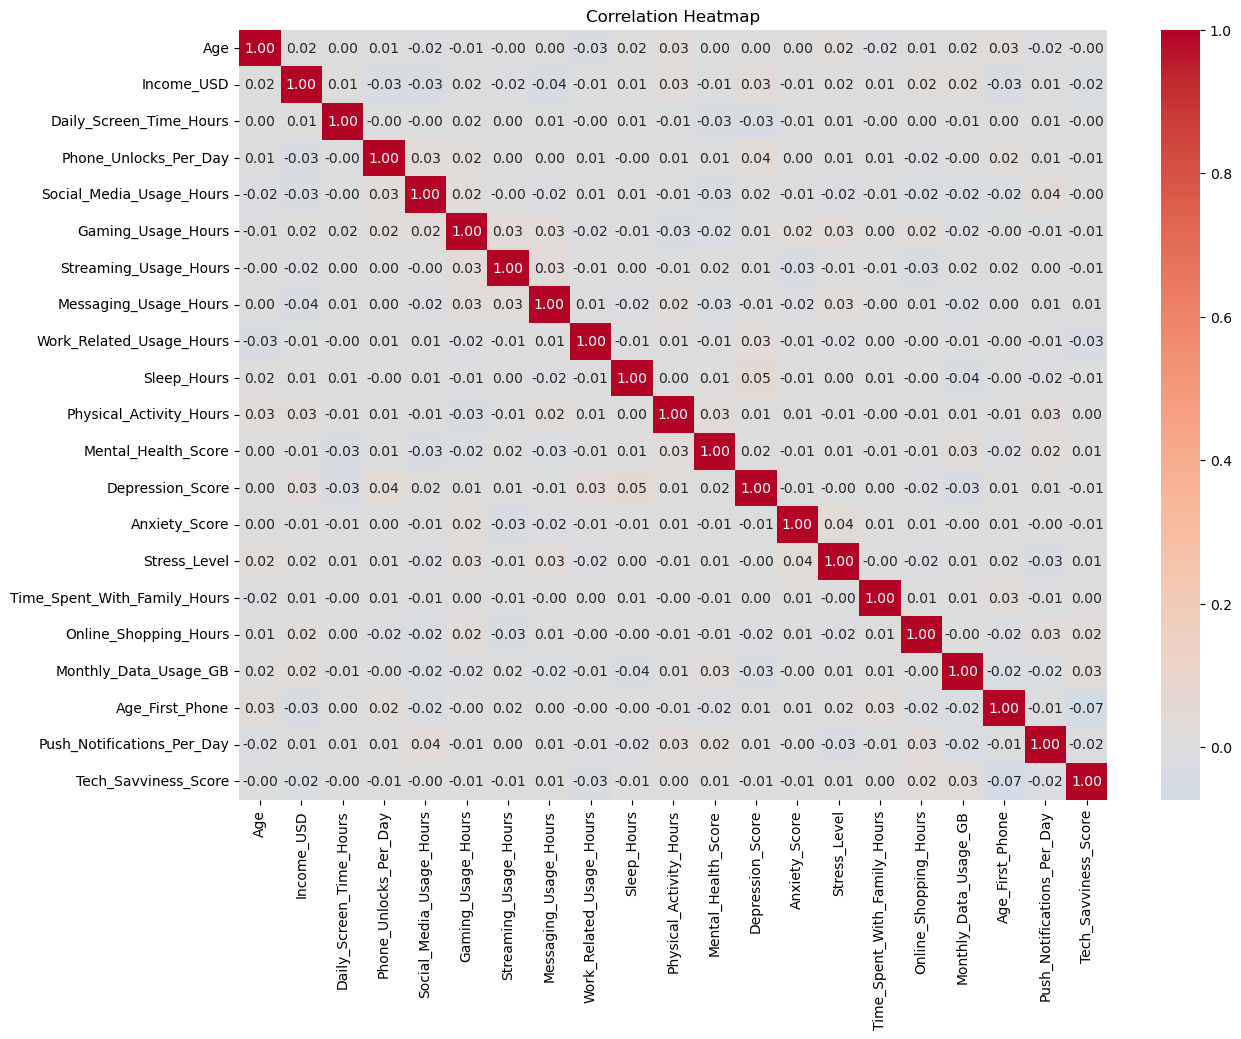

In [10]:
plt.figure(figsize=(14, 10))
numerical_cols = df.select_dtypes(include=['float64', 'int64']).drop(columns=["User_ID"])
corr_matrix = numerical_cols.corr()
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.show()